# Forget

In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com' # Set Hugging Face endpoint to a mirror
os.chdir('./Interkcat')

In [2]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from model import InterKcat, KcatDataset, collate_fn
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### Dataloder

In [3]:
# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 1234
EPOCHS = 200

df = pd.read_csv('EITLEM_KCAT.csv')
sequences = df['Sequence'].to_list()
smiles_list = df['Smiles'].to_list()
kcats = np.log10(df['Value']).values

# Split  Train : Dev : Test = 80 : 10 : 10
train_seq, temp_seq, train_smiles, temp_smiles, train_kcat, temp_kcat = train_test_split(
        sequences, smiles_list, kcats,
        test_size=0.2,
        random_state=SEED
    )


dev_seq, test_seq, dev_smiles, test_smiles, dev_kcat, test_kcat = train_test_split(
    temp_seq, temp_smiles, temp_kcat,
    test_size=0.5,
    random_state=SEED
)

# Dataset
train_dataset = KcatDataset(train_seq, train_smiles, train_kcat)
dev_dataset = KcatDataset(dev_seq, dev_smiles, dev_kcat)
test_dataset = KcatDataset(test_seq, test_smiles, test_kcat)

### model loading and evaluation

In [ ]:
# Load best model and evaluate on test set
model_path = './interkcat_both_lr0.0001_bs128_md256/best_interkcat_model.pth'
model = InterKcat(prot_dim=640, mol_dim=256).to(DEVICE)
model.load_state_dict(torch.load(model_path))
model.eval()

In [ ]:
# Model evaluation on test set
SEED = 1234 # Same with others
BATCH_SIZE = 256

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

all_val_preds, all_val_targets = [], []
with torch.no_grad():
    for seq_batch, smiles_batch, kcat_batch in test_loader:
        kcat_pred = model(
            protein_sequences=seq_batch,
            smiles_list=smiles_batch,
            inter_model="both"
        )

        all_val_preds.append(kcat_pred.cpu().numpy())
        all_val_targets.append(kcat_batch.cpu().numpy())

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


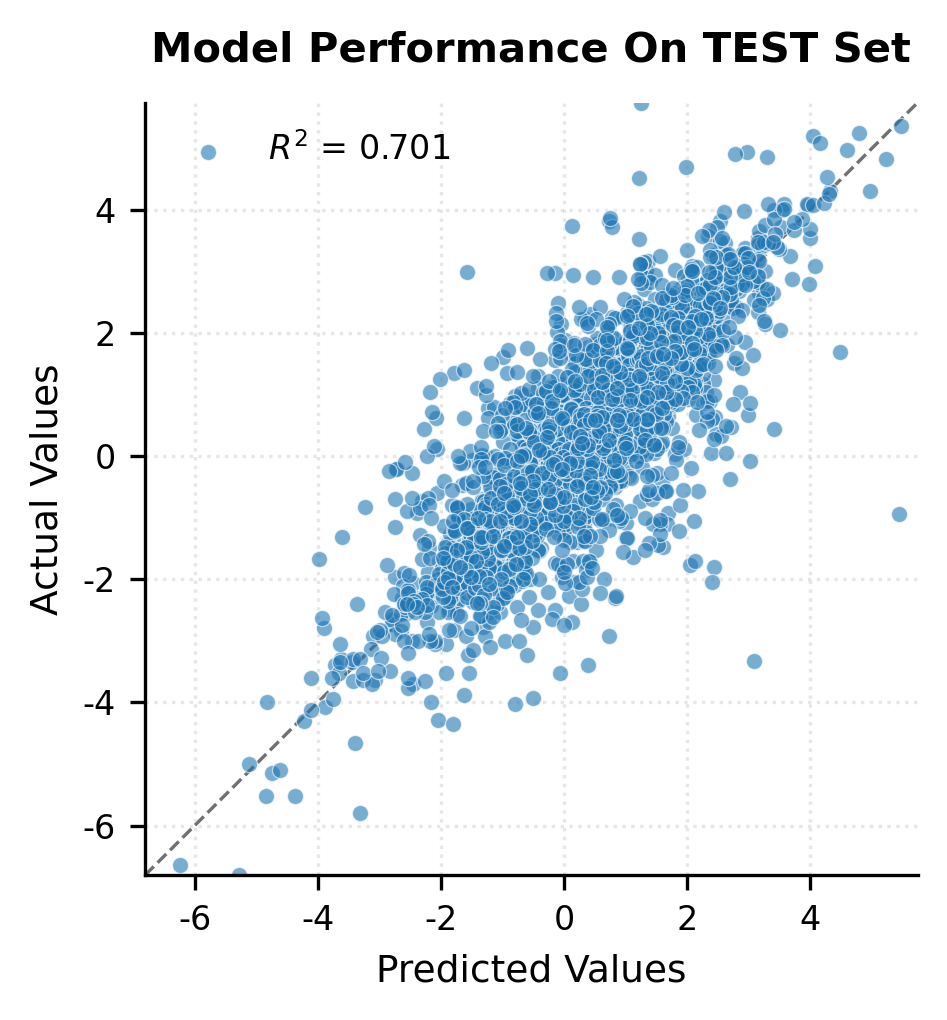

In [7]:
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

all_val_preds = np.concatenate(all_val_preds)
all_val_targets = np.concatenate(all_val_targets)
r2 = r2_score(all_val_targets, all_val_preds)

# ----Style Settings----
font_list = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in font_list:
    plt.rcParams['font.sans-serif'] = ['Arial']
elif 'Helvetica' in font_list:
    plt.rcParams['font.sans-serif'] = ['Helvetica']
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=300)
ax.scatter(all_val_preds, all_val_targets, 
           s=15,
           c='#1f77b4',
           alpha=0.6, 
           edgecolors='white',
           linewidths=0.3,
           label=f'$R^2$ = {r2:.3f}', 
           zorder=2)

lims = [
    np.min([all_val_preds.min(), all_val_targets.min()]),
    np.max([all_val_preds.max(), all_val_targets.max()]),
]
ax.plot(lims, lims, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7, zorder=1)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title('Model Performance On TEST Set', fontsize=10, fontweight='bold', pad=10)
ax.set_xlabel('Predicted Values', fontsize=9)
ax.set_ylabel('Actual Values', fontsize=9)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.grid(True, linestyle=':', alpha=0.3, zorder=0)

plt.tight_layout()
# plt.savefig("model_performance(TEST).png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

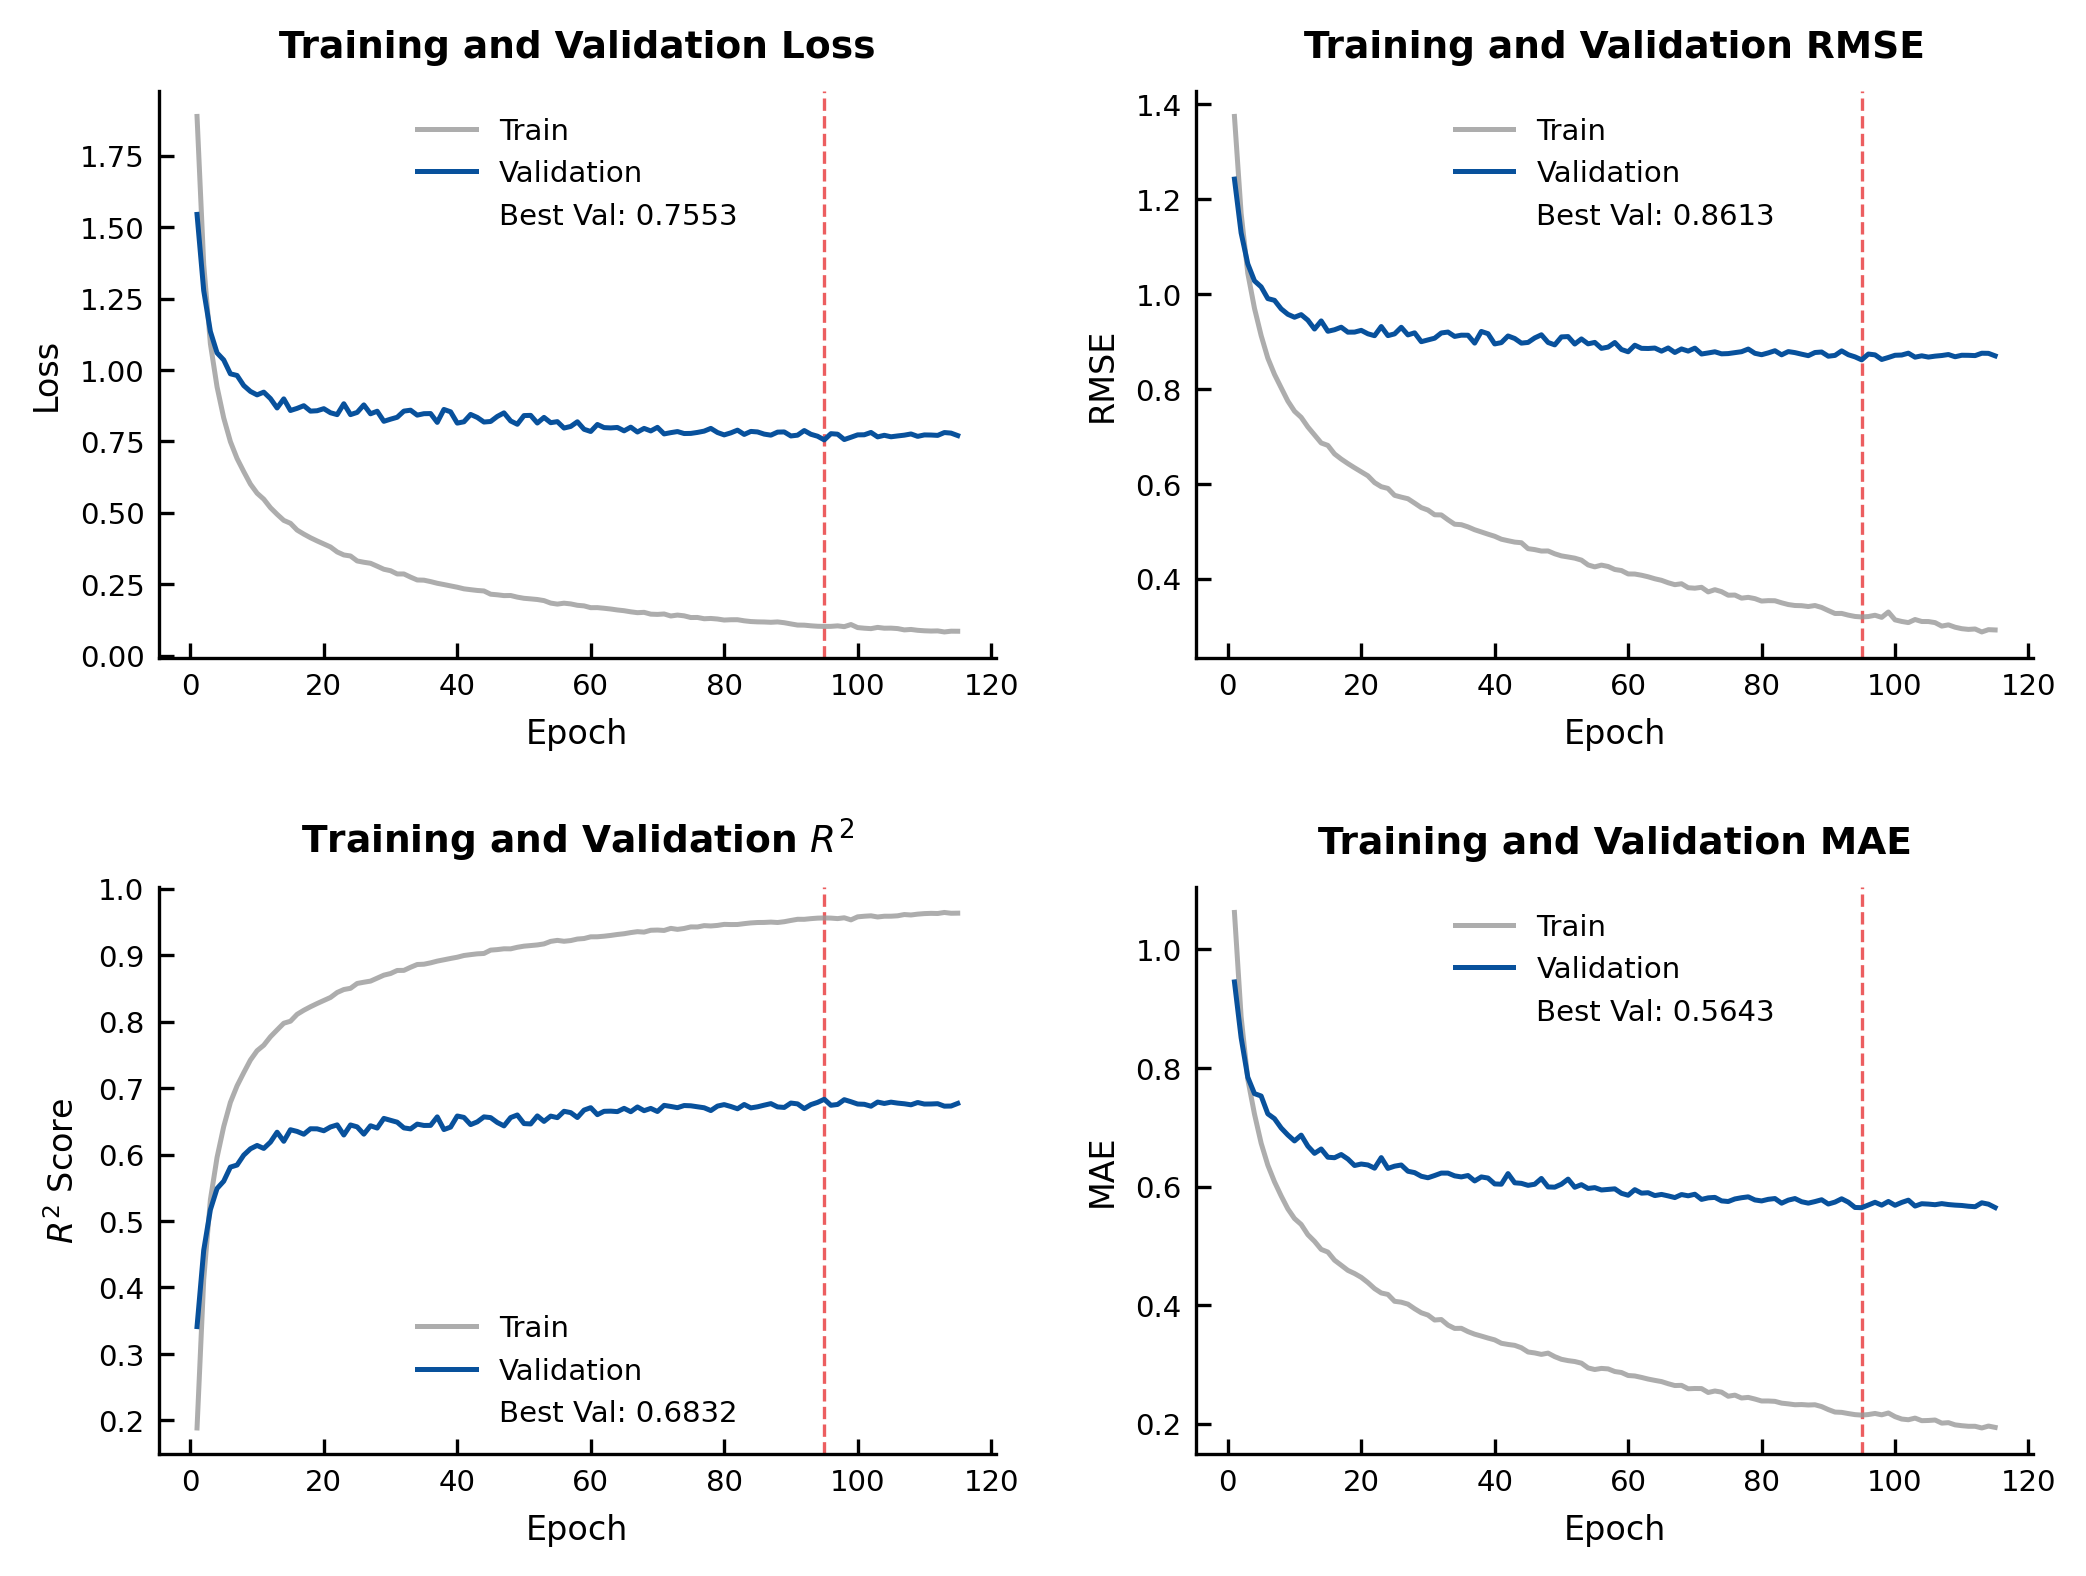

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- Style Configuration ---
font_names = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in font_names:
    plt.rcParams['font.sans-serif'] = ['Arial']
elif 'Helvetica' in font_names:
    plt.rcParams['font.sans-serif'] = ['Helvetica']
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42  # Editable text in Illustrator
})

# ---  Data Loading ---
df = pd.read_csv("./interkcat_both_lr0.0001_bs128_md256/training_metrics.csv")
best_epoch_idx = df['Val_R2'].idxmax()
best_row = df.loc[best_epoch_idx]
best_epoch = int(best_row['Epoch'])
df['Epoch'] = df['Epoch'].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.5), dpi=300)
axes = axes.flatten()
metrics = [
    ('Loss', 'Loss', 'Training and Validation Loss'),
    ('RMSE', 'RMSE', 'Training and Validation RMSE'),
    ('R2', r'$R^2$ Score', r'Training and Validation $R^2$'),
    ('MAE', 'MAE', 'Training and Validation MAE')
]

# Grey for Train, Deep Blue for Validation, Red for best epoch line
c_train = '#999999'
c_val = '#08519c'
c_best_line = '#e41a1c'

for i, (col_base, ylabel, title) in enumerate(metrics):
    ax = axes[i]
    train_col = f'Train_{col_base}'
    val_col = f'Val_{col_base}'
    
    ax.plot(df['Epoch'], df[train_col], label='Train', color=c_train, alpha=0.8)
    ax.plot(df['Epoch'], df[val_col], label='Validation', color=c_val)
    
    ax.axvline(x=best_epoch, color=c_best_line, linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    best_val = best_row[val_col]
    ax.plot([], [], ' ', label=f'Best Val: {best_val:.4f}')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=8)
    ax.legend(frameon=False, loc='best')

fig.tight_layout(pad=2.0)
# plt.savefig("training_metrics_sci_style.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Model Interpretation: Attention Visualization for a Sample Protein-Molecule Pair

In [11]:
i = 100  # sample index

# === Protein Embedding Info ===
prot_emb, prot_mask, prot_symbols = model.prot_emb([sequences[i]], return_symbols=True)
# prot_mask: (1, L_prot), prot_symbols: List[str] of length L_prot

# === Molecule Embedding Info ===
mol_out = model.mol_emb([smiles_list[i]], return_symbols=True)
# mol_out.atom_mask: (1, L_mol), mol_out.atom_symbols: List[str] of length L_mol

# === Attention Maps from Model Output ===
pred, attn_p2m, attn_m2p = model(
    protein_sequences=[sequences[i]],
    smiles_list=[smiles_list[i]],
    inter_model="both",
    return_attn=True
)

# Remove batch dimension (since batch_size=1)
prot_mask = prot_mask.squeeze(0)          # (L_prot,)
mol_mask = mol_out.atom_mask.squeeze(0)   # (L_mol,)
attn_p2m = attn_p2m.squeeze(0)            # (L_prot, L_mol)
attn_m2p = attn_m2p.squeeze(0)            # (L_mol, L_prot)

# Get real lengths (excluding padding)
real_prot_len = prot_mask.sum().item()
real_mol_len = mol_mask.sum().item()

# Extract valid attention submatrices
attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len]   # (P, M) Protein → Molecule The "attention" of each amino acid to each molecular atom
attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len]   # (M, P) Molecule → Protein The "attention" of each molecular atom to each amino acid

# Get corresponding symbols
prot_seq = prot_symbols[0][:real_prot_len]        # List[str], e.g., ['M', 'K', 'T', ...]
mol_atoms = mol_out.atom_symbols[0][:real_mol_len]  # List[str], e.g., ['C', 'O', 'N', ...]

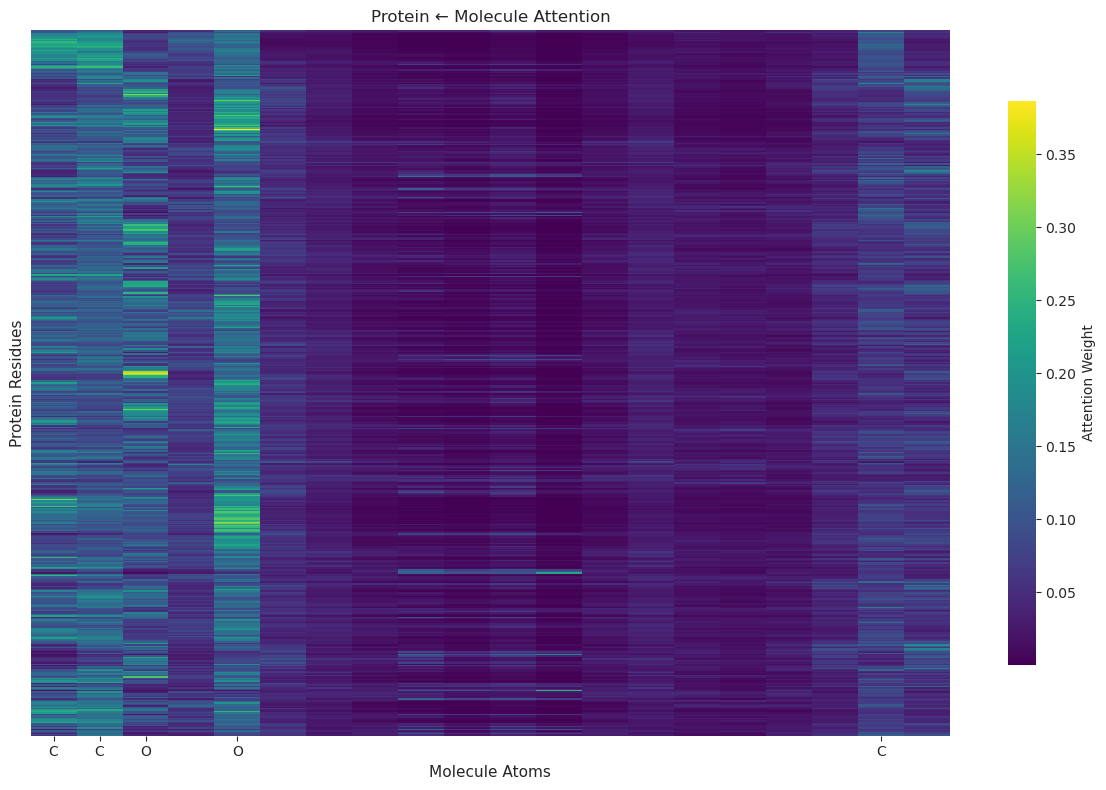

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

attn_real_detached = attn_p2m_real.detach().cpu().numpy()
avg_attn_per_atom = attn_real_detached.mean(axis=0)  # shape: (num_atoms,)
k = min(5, len(avg_attn_per_atom))
top_k_indices = np.argsort(avg_attn_per_atom)[-k:]
top_k_indices = np.sort(top_k_indices)
top_k_labels = [mol_atoms[i] for i in top_k_indices]


plt.figure(figsize=(12, 8))
sns.set_style("ticks")

ax = sns.heatmap(
    attn_real_detached,
    xticklabels=False,          
    yticklabels=False,       
    cmap="viridis",
    cbar_kws={
        'label': 'Attention Weight',
        'shrink': 0.8,      
        'aspect': 20
    },
    linewidths=0,               
    rasterized=True             
)
ax.set_xticks([i + 0.5 for i in top_k_indices])
ax.set_xticklabels(top_k_labels, rotation=0, fontsize=10)

plt.xlabel("Molecule Atoms", fontsize=11)
plt.ylabel("Protein Residues", fontsize=11)
plt.title("Protein ← Molecule Attention", fontsize=12)
plt.tight_layout()
# plt.savefig("protein_to_molecule_attention_real.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

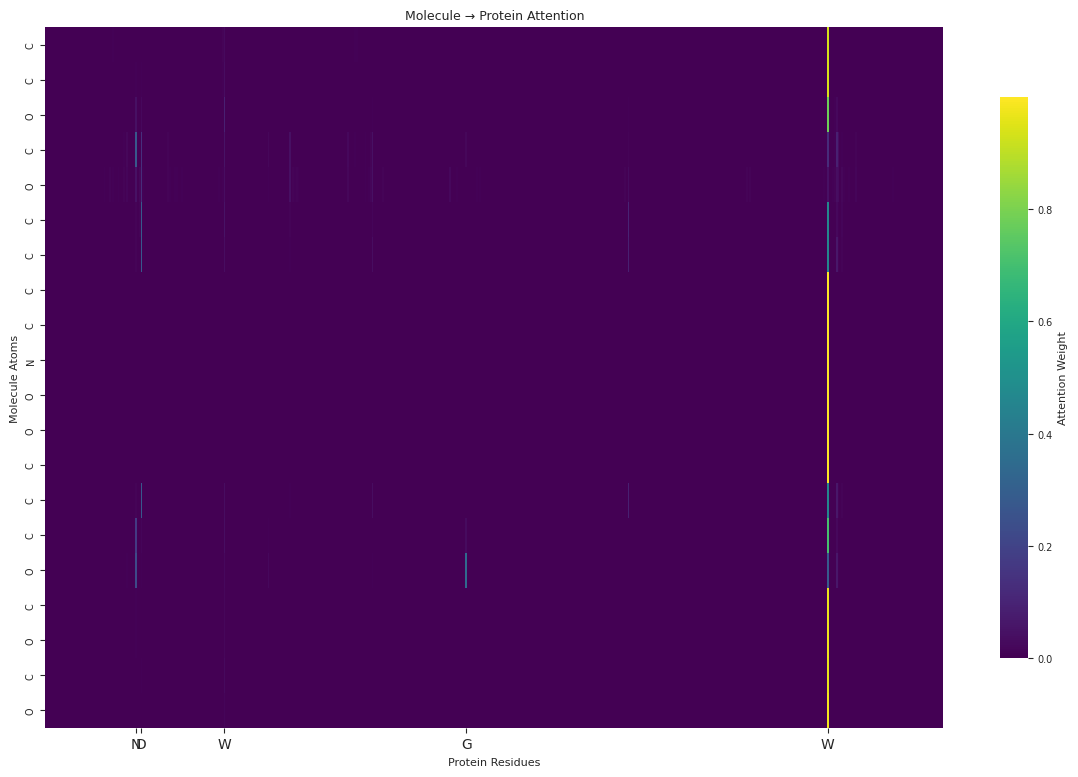

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

attn_real_detached = attn_m2p_real.detach().cpu().numpy()
avg_attn_per_residue = attn_real_detached.mean(axis=0)  # shape: (num_residues,)
k = min(5, len(avg_attn_per_residue))
top_k_indices = np.argsort(avg_attn_per_residue)[-k:]
top_k_indices = np.sort(top_k_indices)
top_k_labels = [prot_seq[i] for i in top_k_indices]

plt.figure(figsize=(12, 8))
sns.set_style("ticks")

ax = sns.heatmap(
    attn_real_detached,
    xticklabels=False,
    yticklabels=mol_atoms,
    cmap="viridis",
    cbar_kws={
        'label': 'Attention Weight',
        'shrink': 0.8,      
        'aspect': 20
    },
    linewidths=0,               
    rasterized=True
)

ax.set_xticks([i + 0.5 for i in top_k_indices])
ax.set_xticklabels(top_k_labels, rotation=0, fontsize=10)

plt.xlabel("Protein Residues")
plt.ylabel("Molecule Atoms")
plt.title("Molecule → Protein Attention")
plt.tight_layout()
# plt.savefig("molecule_to_protein_attention_real.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Statistical Analysis

In [25]:
import numpy as np
from collections import Counter
from tqdm import tqdm

threshold = 0.50

# High-Attention & Background
high_seq_symbols = []  # To store high-attention amino acids
high_mol_symbols = []  # To store high-attention atoms

bg_seq_symbols = []    # To store ALL amino acids (Background)
bg_mol_symbols = []    # To store ALL atoms (Background)

def get_top_p_elements(scores, symbols, threshold):
    sorted_idx = np.argsort(scores)[::-1]
    cum_scores = np.cumsum(scores[sorted_idx])
    cutoff = np.searchsorted(cum_scores, threshold) + 1
    top_idx = np.sort(sorted_idx[:cutoff])
    return [symbols[i] for i in top_idx]

print("Processing attention matrices for all samples...")

for i in tqdm(range(len(sequences)), desc="Processing samples"):
    prot_emb, prot_mask, prot_symbols = model.prot_emb([sequences[i]], return_symbols=True)
    mol_out = model.mol_emb([smiles_list[i]], return_symbols=True)
    
    pred, attn_p2m, attn_m2p = model(
        protein_sequences=[sequences[i]], smiles_list=[smiles_list[i]],
        inter_model="both", return_attn=True
    )

    prot_mask = prot_mask.squeeze(0)
    mol_mask = mol_out.atom_mask.squeeze(0)
    attn_p2m = attn_p2m.squeeze(0)
    attn_m2p = attn_m2p.squeeze(0)

    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_mask.sum().item()

    attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len]
    attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len]

    prot_seq = prot_symbols[0][:real_prot_len]
    mol_atoms = mol_out.atom_symbols[0][:real_mol_len]

    attn_m2p_np = attn_m2p_real.detach().cpu().numpy()
    attn_p2m_np = attn_p2m_real.detach().cpu().numpy()
    aa_scores_norm = attn_m2p_np.sum(axis=0) / attn_m2p_np.sum()
    mol_scores_norm = attn_p2m_np.sum(axis=0) / attn_p2m_np.sum()

    top_aas = get_top_p_elements(aa_scores_norm, prot_seq, threshold)
    top_atoms = get_top_p_elements(mol_scores_norm, mol_atoms, threshold)
    
    # Append to respective lists
    high_seq_symbols.extend(top_aas)
    high_mol_symbols.extend(top_atoms)
    
    bg_seq_symbols.extend(prot_seq)
    bg_mol_symbols.extend(mol_atoms)

Processing attention matrices for all samples...


Processing samples: 100%|█████████████████| 34140/34140 [18:04<00:00, 31.49it/s]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chisquare
from scipy.interpolate import make_interp_spline

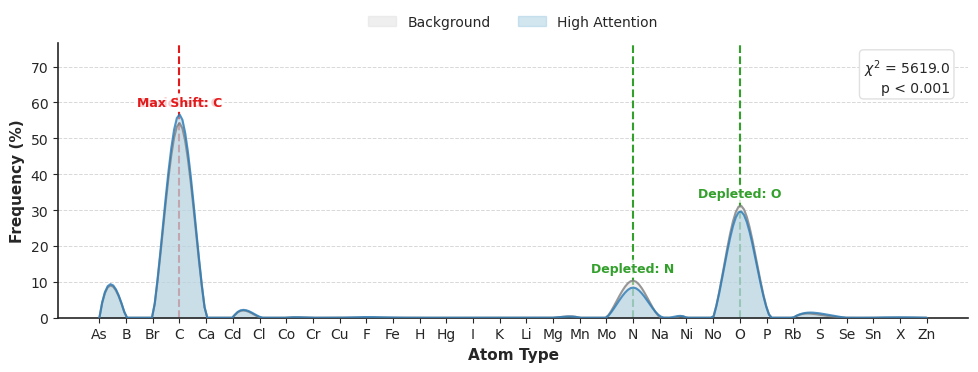

In [35]:
bg_list = bg_mol_symbols
high_list = high_mol_symbols

# count frequencies
bg_counts = Counter(bg_list)
high_counts = Counter(high_list)

unique_symbols = sorted(list(set(bg_list)))

total_bg = sum(bg_counts.values())
total_high = sum(high_counts.values())

bg_freqs = []
high_freqs = []
f_obs = [] 
f_exp = [] 

for sym in unique_symbols:
    bg_freqs.append((bg_counts[sym] / total_bg) * 100 if total_bg > 0 else 0)
    high_freqs.append((high_counts[sym] / total_high) * 100 if total_high > 0 else 0)
    
    observed = high_counts[sym]
    expected = (bg_counts[sym] / total_bg) * total_high
    f_obs.append(observed)
    f_exp.append(expected if expected > 0 else 1e-5)

# chi-square test
chi2_stat, p_value = chisquare(f_obs=f_obs, f_exp=f_exp)
    
# Find symbol with max frequency difference
freq_diffs = np.abs(np.array(high_freqs) - np.array(bg_freqs))
max_diff_idx = np.argmax(freq_diffs)
max_diff_sym = unique_symbols[max_diff_idx]

x = np.arange(len(unique_symbols))
x_smooth = np.linspace(x.min(), x.max(), 300)
spline_bg = make_interp_spline(x, bg_freqs, k=3)
bg_freqs_smooth = np.clip(spline_bg(x_smooth), 0, None)
spline_high = make_interp_spline(x, high_freqs, k=3)
high_freqs_smooth = np.clip(spline_high(x_smooth), 0, None)


fig, ax = plt.subplots(figsize=(10, 4)) 
color_bg, fill_bg = '#808080', '#E0E0E0'
color_high, fill_high = '#2C7BB6', '#A6CEE3'

ax.fill_between(x_smooth, 0, bg_freqs_smooth, color=fill_bg, alpha=0.5, zorder=2, label='Background')
ax.fill_between(x_smooth, 0, high_freqs_smooth, color=fill_high, alpha=0.5, zorder=2, label='High Attention')
ax.plot(x_smooth, bg_freqs_smooth, color=color_bg, linewidth=1.5, zorder=3, alpha=0.8)
ax.plot(x_smooth, high_freqs_smooth, color=color_high, linewidth=1.5, zorder=3, alpha=0.8)

# custom annotations
depleted_syms = ['N','O']
enriched_syms = ['C']

color_depleted = '#33A02C'   # Depleted
color_enriched = '#E31A1C'   # Enriched

marked_indices = set()

# Depleted symbols (N, O)
for sym in depleted_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        ax.axvline(x=idx, color=color_depleted, linestyle='--', linewidth=1.5, zorder=1)
        y_max = max(high_freqs[idx], bg_freqs[idx])
        ax.text(idx, y_max + 1.5, f"Depleted: {sym}", 
                color=color_depleted, ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)
        marked_indices.add(idx)

# Enriched symbols (C)
for sym in enriched_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        ax.axvline(x=idx, color=color_enriched, linestyle='--', linewidth=1.5, zorder=1)
        y_max = max(high_freqs[idx], bg_freqs[idx])
        ax.text(idx, y_max + 1.5, f"Enriched: {sym}", 
                color=color_enriched, ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)
        marked_indices.add(idx)

y_max_at_diff = max(high_freqs[max_diff_idx], bg_freqs[max_diff_idx])
ax.text(max_diff_idx, y_max_at_diff + 1.5, f"Max Shift: {max_diff_sym}", 
        color="#E31A1C", ha='center', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)

ax.set_ylim(0, max(max(high_freqs), max(bg_freqs)) * 1.35) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=10)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)

ax.set_ylabel('Frequency (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Atom Type', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(unique_symbols, fontsize=10)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=10)

p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
stats_text = f"$\\chi^2$ = {chi2_stat:.1f}\n{p_text}"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
        ha='right', va='top', fontsize=10, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DDDDDD", alpha=0.9), zorder=6)

plt.tight_layout()
title = "Atom Type Distribution in High-Attention vs Background"
filename_base = title.replace(' ', '_').replace(':', '').lower()
plt.savefig(f"{filename_base}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

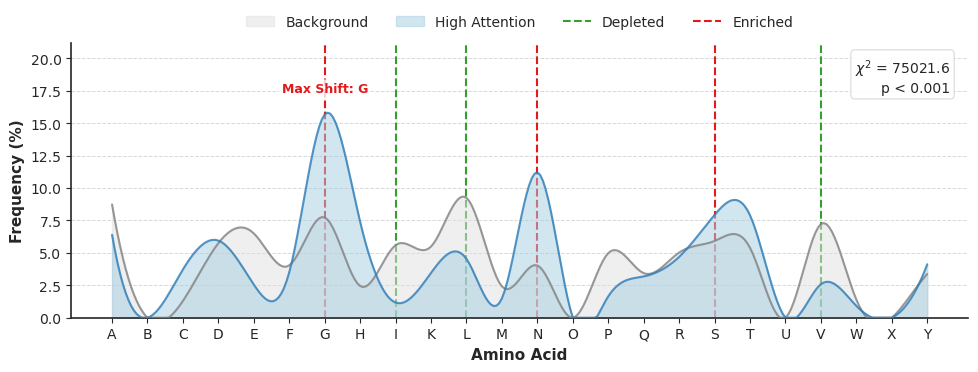

In [33]:
bg_list = bg_seq_symbols
high_list = high_seq_symbols

# count frequencies
bg_counts = Counter(bg_list)
high_counts = Counter(high_list)

unique_symbols = sorted(list(set(bg_list)))

total_bg = sum(bg_counts.values())
total_high = sum(high_counts.values())

bg_freqs = []
high_freqs = []
f_obs = [] 
f_exp = [] 

for sym in unique_symbols:
    bg_freqs.append((bg_counts[sym] / total_bg) * 100 if total_bg > 0 else 0)
    high_freqs.append((high_counts[sym] / total_high) * 100 if total_high > 0 else 0)
    
    observed = high_counts[sym]
    expected = (bg_counts[sym] / total_bg) * total_high
    f_obs.append(observed)
    f_exp.append(expected if expected > 0 else 1e-5)

# chi-square test
chi2_stat, p_value = chisquare(f_obs=f_obs, f_exp=f_exp)
    
# Find symbol with max frequency difference
freq_diffs = np.abs(np.array(high_freqs) - np.array(bg_freqs))
max_diff_idx = np.argmax(freq_diffs)
max_diff_sym = unique_symbols[max_diff_idx]

x = np.arange(len(unique_symbols))
x_smooth = np.linspace(x.min(), x.max(), 300)
spline_bg = make_interp_spline(x, bg_freqs, k=3)
bg_freqs_smooth = np.clip(spline_bg(x_smooth), 0, None)
spline_high = make_interp_spline(x, high_freqs, k=3)
high_freqs_smooth = np.clip(spline_high(x_smooth), 0, None)


fig, ax = plt.subplots(figsize=(10, 4)) 
color_bg, fill_bg = '#808080', '#E0E0E0'
color_high, fill_high = '#2C7BB6', '#A6CEE3'

ax.fill_between(x_smooth, 0, bg_freqs_smooth, color=fill_bg, alpha=0.5, zorder=2, label='Background')
ax.fill_between(x_smooth, 0, high_freqs_smooth, color=fill_high, alpha=0.5, zorder=2, label='High Attention')
ax.plot(x_smooth, bg_freqs_smooth, color=color_bg, linewidth=1.5, zorder=3, alpha=0.8)
ax.plot(x_smooth, high_freqs_smooth, color=color_high, linewidth=1.5, zorder=3, alpha=0.8)

# custom annotations
depleted_syms = ['I', 'L', 'V']
enriched_syms = ['N', 'G', 'S']

color_depleted = '#33A02C'   # Depleted
color_enriched = '#E31A1C'   # Enriched

marked_indices = set()

# Depleted symbols (I, L, V)
depleted_labeled = False
for sym in depleted_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        label = 'Depleted' if not depleted_labeled else None
        ax.axvline(x=idx, color=color_depleted, linestyle='--', linewidth=1.5, zorder=1, label=label)
        depleted_labeled = True
        marked_indices.add(idx)

# Enriched symbols (N, G, S)
enriched_labeled = False
for sym in enriched_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        label = 'Enriched' if not enriched_labeled else None
        ax.axvline(x=idx, color=color_enriched, linestyle='--', linewidth=1.5, zorder=1, label=label)
        enriched_labeled = True
        marked_indices.add(idx)

# Max difference annotation
y_max_at_diff = max(high_freqs[max_diff_idx], bg_freqs[max_diff_idx])
ax.text(max_diff_idx, y_max_at_diff + 1.5, f"Max Shift: {max_diff_sym}", 
        color='#E31A1C', ha='center', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)

ax.set_ylim(0, max(max(high_freqs), max(bg_freqs)) * 1.35) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=10)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)

ax.set_ylabel('Frequency (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Amino Acid', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(unique_symbols, fontsize=10)

ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=10)

p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
stats_text = f"$\\chi^2$ = {chi2_stat:.1f}\n{p_text}"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
        ha='right', va='top', fontsize=10, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DDDDDD", alpha=0.9), zorder=6)

plt.tight_layout()
title = "Amino Acid Distribution in High-Attention vs Background"
filename_base = title.replace(' ', '_').replace(':', '').lower()
plt.savefig(f"{filename_base}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Group Analysis by EC Number

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('EITLEM_KCAT.csv')
# EC class
df['EC_Main_Class'] = df['ECNumber'].astype(str).apply(lambda x: x.split('.')[0])
df['EC_Main_Class'] = 'EC ' + df['EC_Main_Class']
# df.to_csv('EITLEM_KCAT_grouped.csv', index=False)

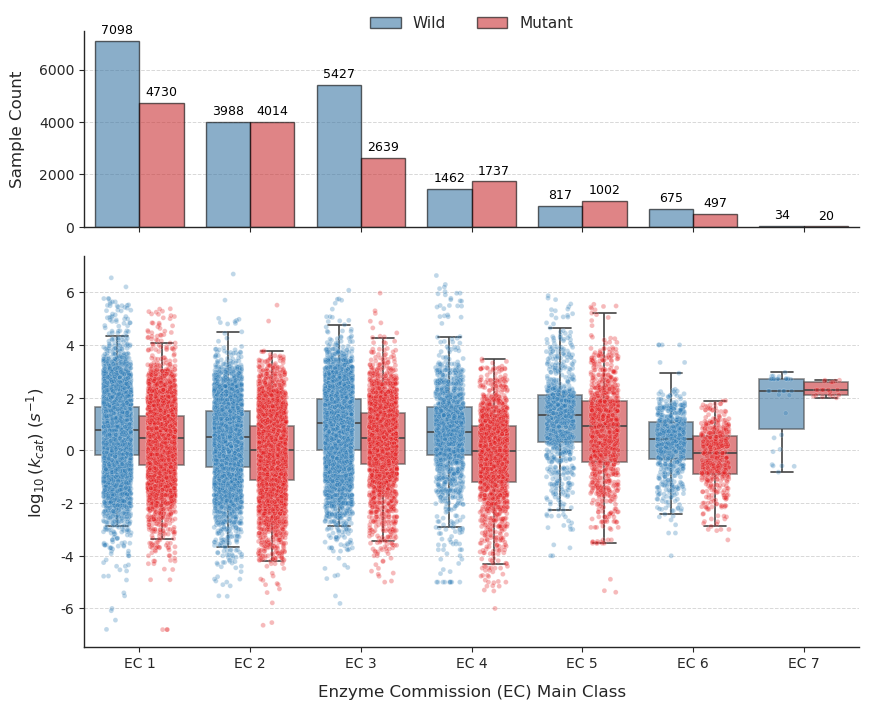

In [37]:
plot_df = df.dropna(subset=['EC_Main_Class', 'Value', 'type']).copy()
valid_ecs = [f"EC {i}" for i in range(1, 8)]
plot_df = plot_df[plot_df['EC_Main_Class'].isin(valid_ecs)]
plot_df = plot_df[plot_df['Value'] > 0]
plot_df['Log_kcat'] = np.log10(plot_df['Value'])
plot_df['type'] = plot_df['type'].str.capitalize()

# --- Style Configuration ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.0

palette = {'Wild': '#2C7BB6', 'Mutant': '#E31A1C'}
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8),
                               gridspec_kw={'height_ratios': [1, 2]}, sharex=True)

# Plot 1: Sample Counts per EC Class
sns.countplot(
    x='EC_Main_Class', hue='type', data=plot_df, 
    order=valid_ecs, palette=palette, ax=ax1, 
    edgecolor='black', linewidth=1.0, alpha=0.6
)

ax1.set_ylabel('Sample Count', fontsize=12, labelpad=10)
ax1.set_xlabel('')
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:2], labels[:2], frameon=False, loc='upper center', 
           bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=11)

for p in ax1.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    ax1.annotate(f'{int(height)}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=9, color='black', 
                 xytext=(0, 3), textcoords='offset points')

# Plot 2: kcat Distribution per EC Class
sns.boxplot(
    x='EC_Main_Class', y='Log_kcat', hue='type', data=plot_df, 
    order=valid_ecs, palette=palette, fliersize=0, 
    linewidth=1.2, ax=ax2, boxprops=dict(alpha=0.6)
)

sns.stripplot(
    x='EC_Main_Class', y='Log_kcat', hue='type', data=plot_df, 
    order=valid_ecs, palette=palette, dodge=True, alpha=0.3, 
    size=3.5, jitter=0.25, ax=ax2, edgecolor='white', linewidth=0.3
)

ax2.set_ylabel(r'$\log_{10}(k_{cat})$ ($s^{-1}$)', fontsize=12, labelpad=10)
ax2.set_xlabel('Enzyme Commission (EC) Main Class', fontsize=12, labelpad=10)
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=10)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)

plt.subplots_adjust(hspace=0.1)
filename = "kcat_distribution_and_counts_ec"
# plt.savefig(f"{filename}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [38]:
from tqdm import tqdm

def calculate_normalized_entropy(scores_1d):
    length = len(scores_1d)
    if length <= 1:
        return 0.0
    probs = scores_1d / (scores_1d.sum() + 1e-9)
    probs = probs[probs > 1e-9]
    raw_entropy = -np.sum(probs * np.log2(probs))
    return raw_entropy / np.log2(length)

Entropy_seq_list = []
Entropy_mol_list = []

for i in tqdm(range(len(sequences)), desc="Processing samples"):
    prot_emb, prot_mask, prot_symbols = model.prot_emb([sequences[i]], return_symbols=True)
    mol_out = model.mol_emb([smiles_list[i]], return_symbols=True)
    
    pred, attn_p2m, attn_m2p = model(
        protein_sequences=[sequences[i]], smiles_list=[smiles_list[i]],
        inter_model="both", return_attn=True
    )

    prot_mask = prot_mask.squeeze(0)
    mol_mask = mol_out.atom_mask.squeeze(0)
    attn_p2m = attn_p2m.squeeze(0)
    attn_m2p = attn_m2p.squeeze(0)

    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_mask.sum().item()

    attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len].detach().cpu().numpy() # (P, M)
    attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len].detach().cpu().numpy() # (M, P)

    # Molecule Entropy)
    mol_scores = attn_p2m_real.sum(axis=0)
    entropy_mol = calculate_normalized_entropy(mol_scores)
    
    # Sequence Entropy
    aa_scores = attn_m2p_real.sum(axis=0)
    entropy_seq = calculate_normalized_entropy(aa_scores)

    Entropy_seq_list.append(entropy_seq)
    Entropy_mol_list.append(entropy_mol)

df['Entropy_seq_norm'] = Entropy_seq_list
df['Entropy_mol_norm'] = Entropy_mol_list

Processing samples: 100%|█████████████████| 34140/34140 [18:05<00:00, 31.46it/s]


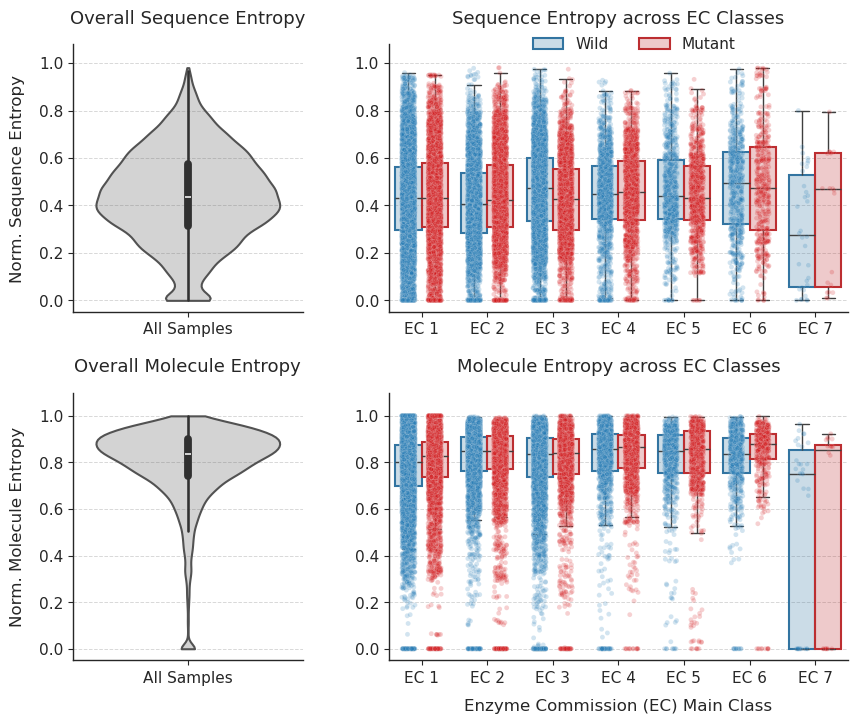

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.collections as collections

df = pd.read_csv('EITLEM_KCAT_with_entropy.csv')
plot_df = df.dropna(subset=['EC_Main_Class', 'type', 'Entropy_seq_norm', 'Entropy_mol_norm']).copy()
valid_ecs = [f"EC {i}" for i in range(1, 8)]
plot_df = plot_df[plot_df['EC_Main_Class'].isin(valid_ecs)]
plot_df['type'] = plot_df['type'].str.capitalize()
plot_df['Overall'] = 'All Samples'

# --- Style Configuration ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.0

palette_dark = {'Wild': '#1F78B4', 'Mutant': "#D3171AA9"}
color_overall_dark = '#525252'

def apply_custom_fill_edge(ax):
    for patch in ax.patches:
        color = patch.get_facecolor()
        patch.set_facecolor((color[0], color[1], color[2], 0.25))
        patch.set_edgecolor((color[0], color[1], color[2], 1.0))
        patch.set_linewidth(1.5)
        
    for collection in ax.collections:
        if isinstance(collection, collections.PolyCollection):
            colors = collection.get_facecolor()
            if len(colors) > 0:
                color = colors[0]
                collection.set_facecolor((color[0], color[1], color[2], 0.25))
                collection.set_edgecolor((color[0], color[1], color[2], 1.0))
                collection.set_linewidth(1.5)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), 
                         gridspec_kw={'width_ratios': [1, 2], 'wspace': 0.25, 'hspace': 0.3})

y_max_seq = plot_df['Entropy_seq_norm'].max()
y_max_mol = plot_df['Entropy_mol_norm'].max()

# Protein Sequence Entropy
sns.violinplot(x='Overall', y='Entropy_seq_norm', data=plot_df,
               color=color_overall_dark, inner='box', cut=0, ax=axes[0, 0])
apply_custom_fill_edge(axes[0, 0])

axes[0, 0].set_title('Overall Sequence Entropy', fontsize=13, pad=15)
axes[0, 0].set_ylabel('Norm. Sequence Entropy', fontsize=12, labelpad=10)
axes[0, 0].set_xlabel('')

# EC-wise Seq Entropy
sns.boxplot(x='EC_Main_Class', y='Entropy_seq_norm', hue='type', data=plot_df, 
            order=valid_ecs, palette=palette_dark, fliersize=0, ax=axes[0, 1])
apply_custom_fill_edge(axes[0, 1])
sns.stripplot(x='EC_Main_Class', y='Entropy_seq_norm', hue='type', data=plot_df, 
              order=valid_ecs, palette=palette_dark, dodge=True, alpha=0.2, 
              size=3.5, jitter=0.2, ax=axes[0, 1], edgecolor='white', linewidth=0.3)

axes[0, 1].set_title('Sequence Entropy across EC Classes', fontsize=13, pad=15)
axes[0, 1].set_ylabel('')
axes[0, 1].set_xlabel('')


handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles[:2], labels[:2], frameon=False, fontsize=11, ncol = 2, loc=[0.3, 0.95])

# Substrate Molecule Entropy
sns.violinplot(x='Overall', y='Entropy_mol_norm', data=plot_df,
               color=color_overall_dark, inner='box', cut=0, ax=axes[1, 0])
apply_custom_fill_edge(axes[1, 0])

axes[1, 0].set_title('Overall Molecule Entropy', fontsize=13, pad=15)
axes[1, 0].set_ylabel('Norm. Molecule Entropy', fontsize=12, labelpad=10)
axes[1, 0].set_xlabel('')

# EC-wise Mol Entropy
sns.boxplot(x='EC_Main_Class', y='Entropy_mol_norm', hue='type', data=plot_df, 
            order=valid_ecs, palette=palette_dark, fliersize=0, ax=axes[1, 1])
apply_custom_fill_edge(axes[1, 1])
sns.stripplot(x='EC_Main_Class', y='Entropy_mol_norm', hue='type', data=plot_df, 
              order=valid_ecs, palette=palette_dark, dodge=True, alpha=0.2, 
              size=3.5, jitter=0.2, ax=axes[1, 1], edgecolor='white', linewidth=0.3)

axes[1, 1].set_title('Molecule Entropy across EC Classes', fontsize=13, pad=15)
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlabel('Enzyme Commission (EC) Main Class', fontsize=12, labelpad=10)

if axes[1, 1].get_legend() is not None:
    axes[1, 1].get_legend().remove()

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=11)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)
        
        if i == 0: ax.set_ylim(-0.05, y_max_seq * 1.1)
        if i == 1: ax.set_ylim(-0.05, y_max_mol * 1.1)

filename = "entropy_distribution_aesthetic"
# plt.savefig(f"{filename}.png", dpi=600, bbox_inches='tight', transparent=True)b
plt.show()

### Sequence-pairs level analysis

In [10]:
import pandas as pd
from difflib import SequenceMatcher
from tqdm import tqdm
from rdkit import Chem
from Bio.Align import PairwiseAligner
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
os.chdir("/data/weiren/Interkcat")

In [11]:
# Function to count mutation sites
def count_mutation_sites(val):
    if pd.isna(val) or val == 'No WT available':
        return pd.NA
    if val == 'WT':
        return 0
    return str(val).count(';') + 1

In [12]:
# Load the dataset
df = pd.read_csv('EITLEM_KCAT_with_mutations.csv')

# parameters
global_aligner = PairwiseAligner()
global_aligner.mode = 'global'
global_aligner.match_score = 2
global_aligner.mismatch_score = -1
global_aligner.open_gap_score = -10
global_aligner.extend_gap_score = -0.5

def extract_mutations_biopython(wt_seq, mut_seq, aligner=global_aligner):
    if pd.isna(wt_seq) or pd.isna(mut_seq):
        return "Invalid Sequence"
    if wt_seq == mut_seq:
        return "No Change"
    
    try:
        alignment = aligner.align(wt_seq, mut_seq)[0]
        seqA = str(alignment[0]) # Aligned WT
        seqB = str(alignment[1]) # Aligned Mutant

        mutations = []
        wt_idx = 1
        i = 0
        
        while i < len(seqA):
            if seqA[i] == seqB[i]:
                wt_idx += 1
                i += 1
            elif seqA[i] != '-' and seqB[i] != '-':
                start_wt = wt_idx
                sub_wt, sub_mut = [], []
                while i < len(seqA) and seqA[i] != '-' and seqB[i] != '-' and seqA[i] != seqB[i]:
                    sub_wt.append(seqA[i])
                    sub_mut.append(seqB[i])
                    wt_idx += 1
                    i += 1
                if len(sub_wt) == 1:
                    mutations.append(f"{sub_wt[0]}{start_wt}{sub_mut[0]}")
                else:
                    mutations.append(f"Sub({''.join(sub_wt)}->{''.join(sub_mut)} @ {start_wt})")
            elif seqB[i] == '-':
                start_wt = wt_idx
                del_wt = []
                while i < len(seqA) and seqB[i] == '-':
                    del_wt.append(seqA[i])
                    wt_idx += 1
                    i += 1
                mutations.append(f"Del({''.join(del_wt)} @ {start_wt})")
            elif seqA[i] == '-':
                ins_pos = wt_idx - 1
                ins_mut = []
                while i < len(seqA) and seqA[i] == '-':
                    ins_mut.append(seqB[i])
                    i += 1
                mutations.append(f"Ins({''.join(ins_mut)} @ {ins_pos})")
                
        return " ; ".join(mutations) if mutations else "No Change"
    except Exception as e:
        return f"Alignment Error"

# Grouping and Mutation Extraction
df['type_lower'] = df['type'].astype(str).str.lower()
df['log_kcat'] = np.log10(df['Value'])
group_keys = ['ECNumber', 'Organism', 'Substrate', 'Smiles']
grouped = df.groupby(group_keys)
print(f"Total unique strictly-matched groups found: {len(grouped)}")

augmented_records = []
group_id_counter = 1

for keys, group in tqdm(grouped, desc="Extracting Mutations"):
    wt_df = group[group['type_lower'] == 'wild']
    mut_df = group[group['type_lower'] == 'mutant']
    
    # only process groups that have exactly one WT and at least one Mutant
    if len(wt_df) == 1 and not mut_df.empty:
        wt_row = wt_df.iloc[0]
        wt_seq = wt_row['Sequence']
        wt_record = wt_row.to_dict()
        wt_record['Mutation_Info'] = 'WT'
        wt_record['Group_ID'] = f"G_{group_id_counter:04d}"
        augmented_records.append(wt_record)

        for _, row in mut_df.iterrows():
            mut_record = row.to_dict()
            mut_seq = row['Sequence']
            mut_record['Mutation_Info'] = extract_mutations_biopython(wt_seq, mut_seq)
            mut_record['Group_ID'] = f"G_{group_id_counter:04d}"
            
            augmented_records.append(mut_record)

        group_id_counter += 1

df_paired_full = pd.DataFrame(augmented_records)
desired_columns = [
    'Group_ID', 'ECNumber', 'Organism', 'Substrate', 'Sequence', 'Smiles', 
    'Value', 'type', 'EC_Main_Class', 'Entropy_seq_norm', 
    'Entropy_mol_norm', 'log_kcat', 'Mutation_Info'
]
final_cols = [col for col in desired_columns if col in df_paired_full.columns]
df_final = df_paired_full[final_cols]
# df_final.to_csv('EITLEM_KCAT_paired_mutations.csv', index=False)

Total unique strictly-matched groups found: 19188


Extracting Mutations: 100%|██████████████| 19188/19188 [00:19<00:00, 963.73it/s]


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('EITLEM_KCAT_paired_mutations.csv')
group_keys = ['ECNumber', 'Organism', 'Substrate', 'Smiles']
delta_records = []

for keys, group in df.groupby(group_keys):
    wt_df = group[group['Mutation_Info'] == 'WT']
    mut_df = group[group['Mutation_Info'] != 'WT']
    
    if not wt_df.empty and not mut_df.empty:
        wt_log_kcat = wt_df.iloc[0]['log_kcat']
        
        for idx, mut_row in mut_df.iterrows():
            mut_log_kcat = mut_row['log_kcat']
            delta_log_kcat = mut_log_kcat - wt_log_kcat
            record = {
                'Group_ID': mut_row['Group_ID'],
                'Sequence': mut_row['Sequence'],
                'Smiles': mut_row['Smiles'],
                'ECNumber': keys[0],
                'Organism': keys[1],
                'Substrate': keys[2],
                'Mutation_Info': mut_row['Mutation_Info'],
                'WT_log_kcat': wt_log_kcat,
                'Mutant_log_kcat': mut_log_kcat,
                'Delta_log_kcat': delta_log_kcat,
                'Abs_Delta_log_kcat': abs(delta_log_kcat)
            }
            delta_records.append(record)

delta_df = pd.DataFrame(delta_records)
delta_df = delta_df.sort_values(by='Abs_Delta_log_kcat', ascending=False).reset_index(drop=True)
# delta_df.to_csv('Mutant-info.csv', index=False)

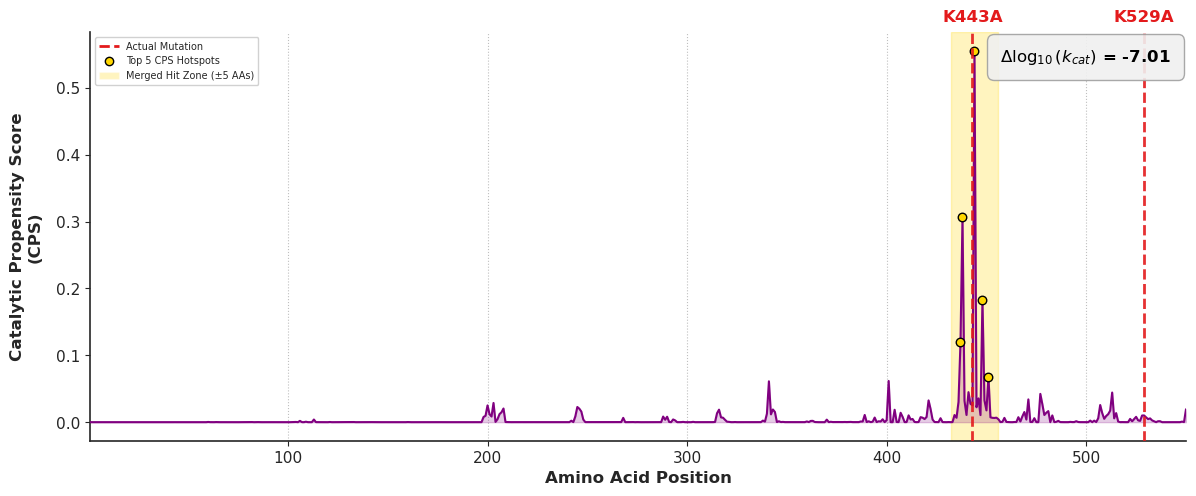

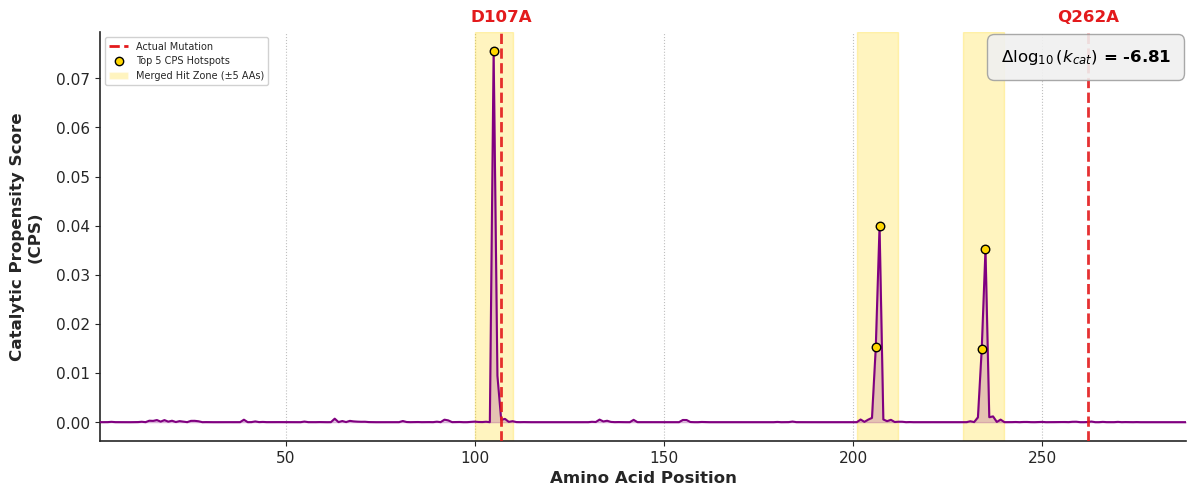

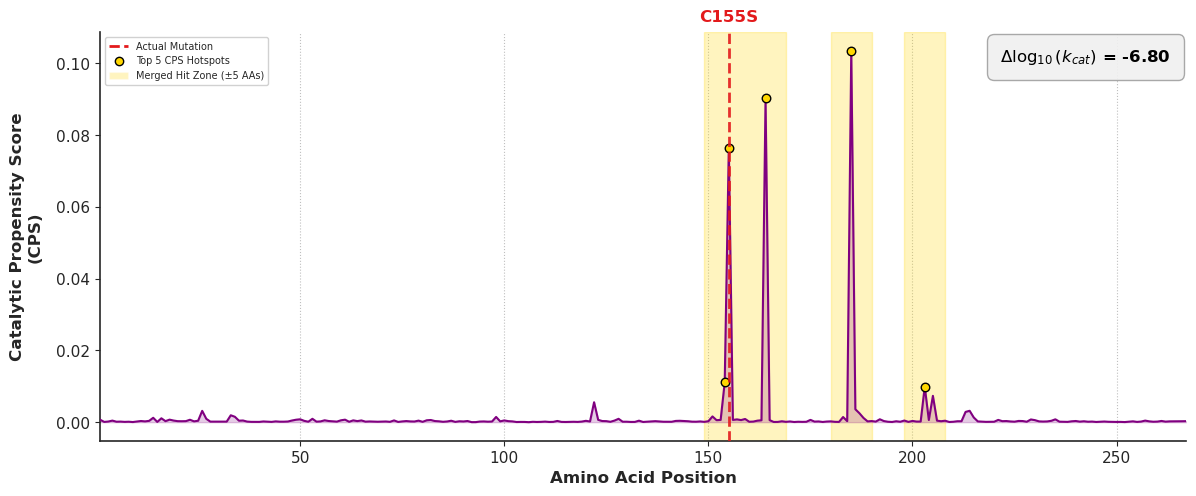

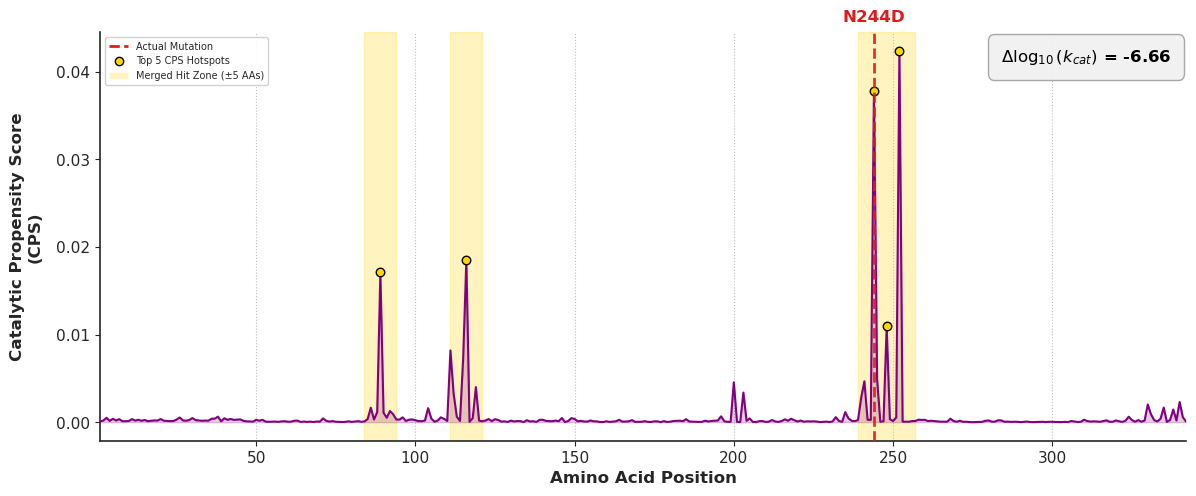

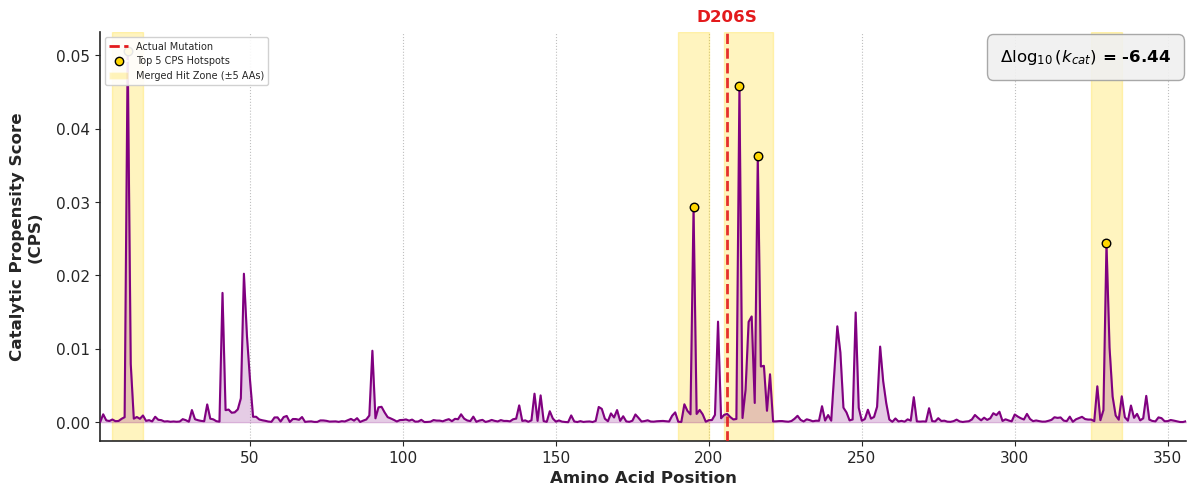

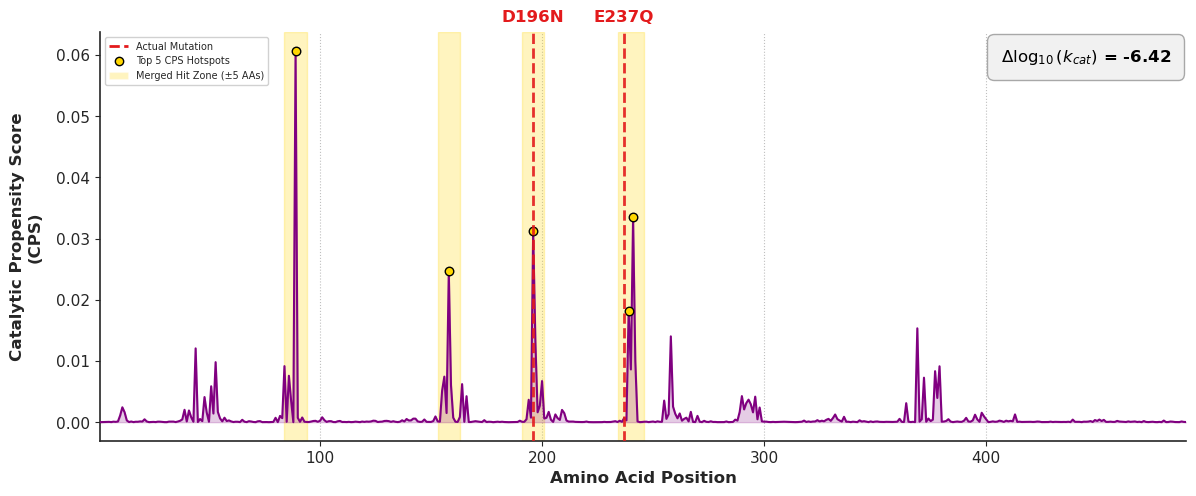

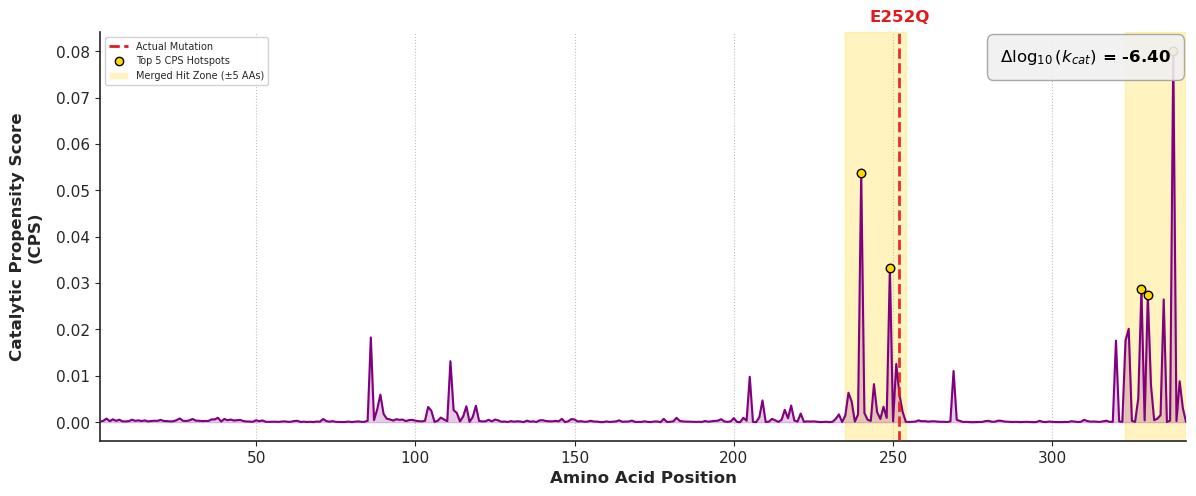

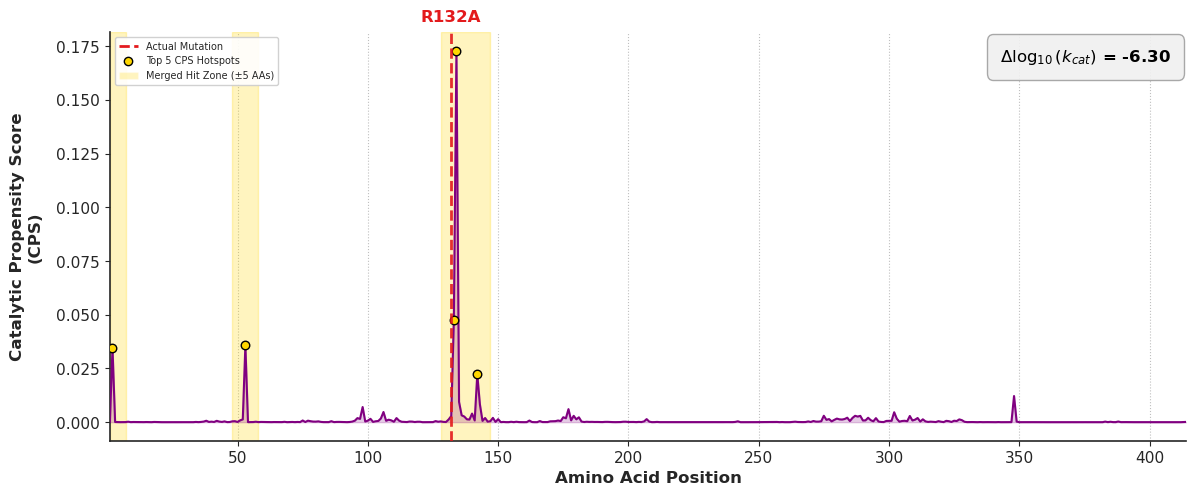

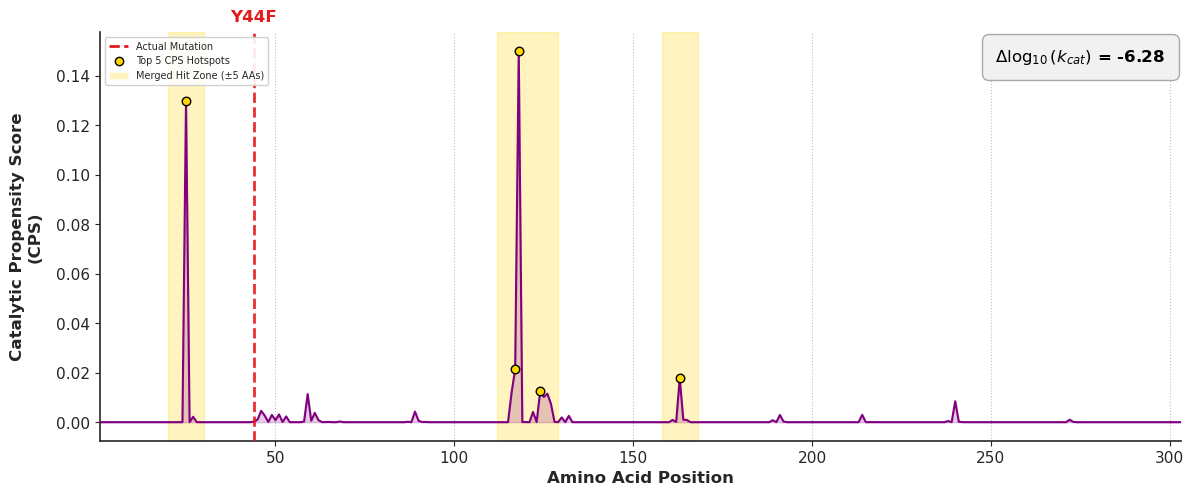

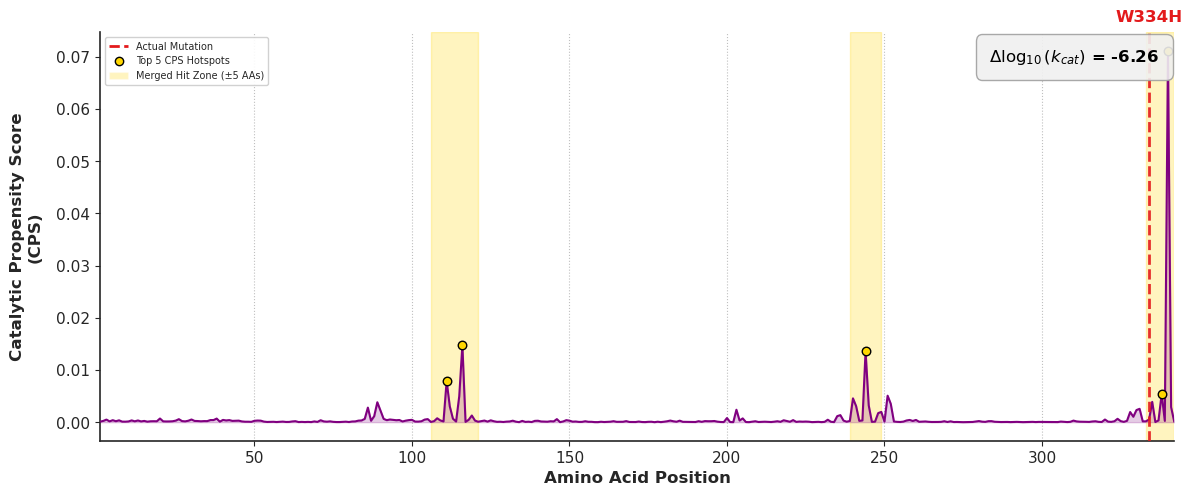

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

# Load the dataset
df_final = pd.read_csv('Mutant-info.csv')

for i in range(10):
    seq = df_final['Sequence'].iloc[i]
    smi = df_final['Smiles'].iloc[i]
    delta_log_kcat = df_final['Delta_log_kcat'].iloc[i]
    mutation_pos = [int(pos) for pos in re.findall(r'\d+', df_final['Mutation_Info'].iloc[i])]
    mutation_text = df_final['Mutation_Info'].iloc[i].split(';')

    # model calculation for the specific sample
    with torch.no_grad():
        prot_emb, prot_mask, prot_symbols = model.prot_emb([seq], return_symbols=True)
        mol_out = model.mol_emb([smi], return_symbols=True)
        pred, attn_p2m, attn_m2p = model(
            protein_sequences=[seq], smiles_list=[smi],
            inter_model="both", return_attn=True
        )
        
    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_out.atom_mask.sum().item()
    start_idx = 1 if len(prot_symbols[0][0]) > 1 else 0
    end_offset = 1 if len(prot_symbols[0][real_prot_len-1]) > 1 else 0
    pure_prot_len = real_prot_len - start_idx - end_offset
    
    attn_p2m_pure = attn_p2m[0, start_idx : real_prot_len - end_offset, :real_mol_len].cpu().numpy()
    attn_m2p_pure = attn_m2p[0, :real_mol_len, start_idx : real_prot_len - end_offset].cpu().numpy()
    
    prot_seq = prot_symbols[0][start_idx : real_prot_len - end_offset]

    # CPS calculation
    aa_weights = attn_m2p_pure.sum(axis=0)
    w_min, w_max = aa_weights.min(), aa_weights.max()
    aa_weights_norm = (aa_weights - w_min) / (w_max - w_min + 1e-9)
    
    def calc_entropy(dist):
        probs = dist[dist > 1e-9]
        if len(dist) <= 1: return 0.0
        return -np.sum(probs * np.log2(probs)) / np.log2(len(dist))
        
    aa_entropies = np.array([calc_entropy(attn_p2m_pure[j, :]) for j in range(pure_prot_len)])
    cps_scores = aa_weights_norm * (1.0 - aa_entropies)
    x_positions = np.arange(1, pure_prot_len + 1)
    
    # parameters for hit zone merging
    radius = 5
    top_5_idx = np.argsort(cps_scores)[-5:]
    top_5_pos = top_5_idx + 1

    # merge hit zones around top 5 positions
    intervals = [[p - radius, p + radius] for p in top_5_pos]
    intervals.sort(key=lambda x: x[0])
    merged_intervals = []
    for interval in intervals:
        if not merged_intervals:
            merged_intervals.append(interval)
        else:
            prev = merged_intervals[-1]
            if interval[0] <= prev[1]:
                prev[1] = max(prev[1], interval[1])
            else:
                merged_intervals.append(interval)

    # --- Style Configuration ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
    plt.rcParams['axes.linewidth'] = 1.2

    fig, ax = plt.subplots(figsize=(12, 5))


    for start, end in merged_intervals:
        real_start = max(1, start)
        real_end = min(len(prot_seq), end)
        ax.axvspan(real_start, real_end, color='#FFD700', alpha=0.25, zorder=1)

    ax.fill_between(x_positions, cps_scores, color='purple', alpha=0.2, zorder=2)
    ax.plot(x_positions, cps_scores, color='purple', linewidth=1.5, zorder=3)

    # Highlight top 5 CPS positions
    ax.scatter(top_5_pos, cps_scores[top_5_idx], color='#FFD700', marker='.', 
            s=150, edgecolor='black', linewidth=1, zorder=4)

    # Highlight actual mutation positions
    for pos in mutation_pos:
        ax.axvline(x=pos, color='#E31A1C', linestyle='--', linewidth=2.0, alpha=0.9, zorder=5)


    ax.set_ylabel('Catalytic Propensity Score\n(CPS)', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_xlabel('Amino Acid Position', fontsize=12, fontweight='bold')

    delta_text = f"$\\Delta\\log_{{10}}(k_{{cat}})$ = {delta_log_kcat:+.2f}"
    anchored_text = AnchoredText(
        delta_text, 
        loc='upper right',
        prop=dict(fontsize=12, fontweight='bold', color='black'),
        frameon=True,
        borderpad=0.5 
    )
    anchored_text.patch.set_boxstyle("round,pad=0.4")
    anchored_text.patch.set_facecolor('#F0F0F0')
    anchored_text.patch.set_edgecolor('#A0A0A0')
    anchored_text.patch.set_alpha(0.9)
    ax.add_artist(anchored_text)

    legend_elements = [
        Line2D([0], [0], color='#E31A1C', lw=2, linestyle='--', label='Actual Mutation'),
        Line2D([0], [0], marker='.', color='w', markerfacecolor='#FFD700', markeredgecolor='black', markersize=12, label='Top 5 CPS Hotspots'),
        Patch(facecolor='#FFD700', alpha=0.25, label=f'Merged Hit Zone (±{radius} AAs)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

    y_max = ax.get_ylim()[1]
    for pos, text in zip(mutation_pos, mutation_text):
        ax.text(pos, y_max * 1.02, f"{text.strip()}", 
                color='#E31A1C', fontsize=12, fontweight='bold', ha='center', va='bottom')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=11)
    ax.xaxis.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=0)

    ax.set_xlim(1, len(prot_seq))

    plt.tight_layout()
    # plt.savefig(f"./Figure/CPS_HitZone_Profile_{i}.png", dpi=600, bbox_inches='tight', transparent=True)
    plt.show()

Analyzing Mutations: 100%|██████████████████████| 10/10 [00:00<00:00, 21.10it/s]


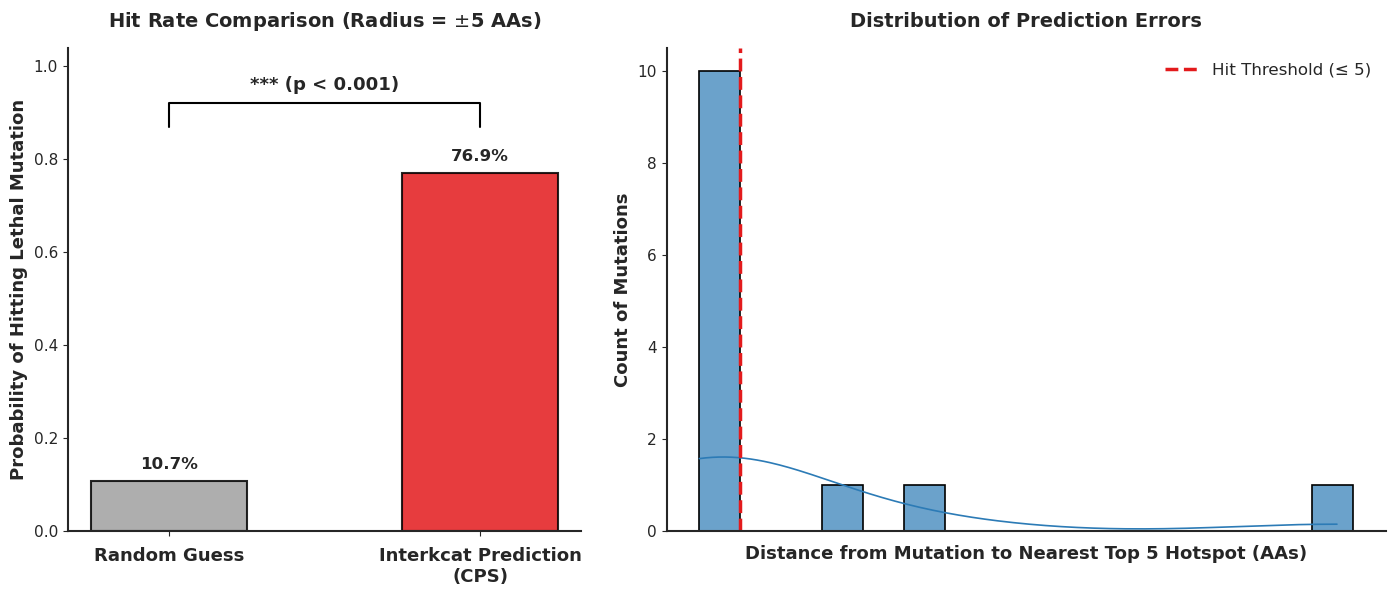


 No Hit Cases:


,Mutation,EC,Mut_Pos,Min_Dist
1,K443A ; K529A,1.13.12.7,529,78
3,D107A ; Q262A,1.1.1.282,262,27
11,Y44F,4.1.3.32,44,19


In [ ]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import binomtest

# Parameters
radius = 5
num_top_samples = 10

# record results for all samples
top_lethal = df_final.head(num_top_samples)
hit_count = 0
total_mut_points = 0
results_log = []

for _, row in tqdm(top_lethal.iterrows(), total=len(top_lethal), desc="Analyzing Mutations"):
    mut_info = row['Mutation_Info']
    mut_positions = [int(p) for p in re.findall(r'\d+', mut_info)]
    if not mut_positions:
        continue
        
    seq = row['Sequence']
    smi = row['Smiles']

    with torch.no_grad():
        prot_emb, prot_mask, prot_symbols = model.prot_emb([seq], return_symbols=True)
        mol_out = model.mol_emb([smi], return_symbols=True)
        pred, attn_p2m, attn_m2p = model(
            protein_sequences=[seq], smiles_list=[smi],
            inter_model="both", return_attn=True
        )
        
    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_out.atom_mask.sum().item()
    start_idx = 1 if len(prot_symbols[0][0]) > 1 else 0
    end_offset = 1 if len(prot_symbols[0][real_prot_len-1]) > 1 else 0
    pure_prot_len = real_prot_len - start_idx - end_offset
    
    attn_p2m_pure = attn_p2m[0, start_idx : real_prot_len - end_offset, :real_mol_len].cpu().numpy()
    attn_m2p_pure = attn_m2p[0, :real_mol_len, start_idx : real_prot_len - end_offset].cpu().numpy()
    
    # CPS Calculation
    aa_weights = attn_m2p_pure.sum(axis=0)
    w_min, w_max = aa_weights.min(), aa_weights.max()
    aa_weights_norm = (aa_weights - w_min) / (w_max - w_min + 1e-9)
    
    def calc_entropy(dist):
        probs = dist[dist > 1e-9]
        if len(dist) <= 1: return 0.0
        return -np.sum(probs * np.log2(probs)) / np.log2(len(dist))
        
    aa_entropies = np.array([calc_entropy(attn_p2m_pure[i, :]) for i in range(pure_prot_len)])
    cps_scores = aa_weights_norm * (1.0 - aa_entropies)
    top_5_pos = np.argsort(cps_scores)[-5:] + 1
    
    # Set-based coverage calculation
    covered_residues = set()
    for pos in top_5_pos:
        start_r = max(1, pos - radius)
        end_r = min(pure_prot_len, pos + radius)
        covered_residues.update(range(start_r, end_r + 1))

    exact_coverage_area = len(covered_residues)
    exact_random_prob = exact_coverage_area / pure_prot_len

    for mp in mut_positions:
        if mp > pure_prot_len: continue 
            
        total_mut_points += 1
        dist = np.min(np.abs(top_5_pos - mp))
        is_hit = dist <= radius
        if is_hit: hit_count += 1
            
        results_log.append({
            'Mutation': mut_info,
            'EC': row['ECNumber'],
            'Seq_Len': pure_prot_len,
            'Mut_Pos': mp,
            'Min_Dist': dist,
            'Is_Hit': is_hit,
            'Exact_Random_Prob': exact_random_prob,
            'Delta_log_kcat': row['Delta_log_kcat']
        })

# Statistical Analysis
df_results = pd.DataFrame(results_log)
hit_rate = hit_count / total_mut_points
avg_random_prob = df_results['Exact_Random_Prob'].mean()
p_value = binomtest(hit_count, total_mut_points, avg_random_prob, alternative='greater').pvalue

# --- Visualization ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.4]})
labels_ax1 = ['Random Guess', 'Interkcat Prediction\n(CPS)']
bars = ax1.bar(labels_ax1, [avg_random_prob, hit_rate], 
               color=['#A0A0A0', '#E31A1C'], alpha=0.85, edgecolor='black', linewidth=1.5, width=0.5)

ax1.set_ylim(0, max(hit_rate, avg_random_prob) * 1.35)
ax1.set_ylabel('Probability of Hitting Lethal Mutation', fontsize=13, fontweight='bold')
ax1.set_title(rf'Hit Rate Comparison (Radius = $\pm${radius} AAs)', fontsize=14, fontweight='bold', pad=15)
ax1.tick_params(axis='x', labelsize=13, pad=8)
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
ax1.tick_params(axis='y', labelsize=11)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

y_max = max(hit_rate, avg_random_prob)
ax1.plot([0, 0, 1, 1], [y_max+0.1, y_max+0.15, y_max+0.15, y_max+0.1], lw=1.5, c='k')
p_text = '*** (p < 0.001)' if p_value < 0.001 else f'p = {p_value:.3f}'
ax1.text(0.5, y_max+0.17, p_text, ha='center', va='bottom', fontsize=13, fontweight='bold')

distances = df_results['Min_Dist'].values
sns.histplot(distances, bins=range(0, int(max(distances))+5, 5), kde=True, ax=ax2, 
             color='#2C7BB6', edgecolor='black', linewidth=1.2, alpha=0.7)

ax2.axvline(x=radius, color='#E31A1C', linestyle='--', linewidth=2.5, label=f'Hit Threshold (≤ {radius})')

ax2.set_xlabel('Distance from Mutation to Nearest Top 5 Hotspot (AAs)', fontsize=13, fontweight='bold', labelpad=10)
ax2.set_ylabel('Count of Mutations', fontsize=13, fontweight='bold')
ax2.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks([])
ax2.tick_params(axis='y', labelsize=11)
ax2.legend(fontsize=12, frameon=False, loc='upper right')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig("./Figure/Statistical_Validation_Hit_Rate.png", bbox_inches='tight', dpi=600, transparent=True)
plt.show()

print("\n No Hit Cases:")
display(df_results[df_results['Is_Hit'] == False][['Mutation', 'EC', 'Mut_Pos', 'Min_Dist']])